<a href="https://colab.research.google.com/github/NathanMagno/energy-consumers-data/blob/ex-21-25/cp04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import seaborn as sb
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

Convertendo o dataset em um dataframe pandas

In [5]:
df = pd.read_csv("household_power_consumption.txt", sep=";", low_memory=False)

1 - Mostrando as 10 primeiras linhas do data frame

In [6]:
df.head(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
5,16/12/2006,17:29:00,3.520,0.522,235.020,15.000,0.000,2.000,17.0
6,16/12/2006,17:30:00,3.702,0.520,235.090,15.800,0.000,1.000,17.0
7,16/12/2006,17:31:00,3.700,0.520,235.220,15.800,0.000,1.000,17.0
8,16/12/2006,17:32:00,3.668,0.510,233.990,15.800,0.000,1.000,17.0
9,16/12/2006,17:33:00,3.662,0.510,233.860,15.800,0.000,2.000,16.0


2 - A Global_active_power é a potência que realiza trabalho útil, convertida em calor, luz ou movimento pelos aparelhos, é o que você paga na conta de luz. Já a Global_reactive_power é a energia que circula em equipamentos como motores e transformadores para criar campos necessários ao seu funcionamento, mas não realiza trabalho útil diretamente. Ou seja, potência ativa faz o trabalho, enquanto a reativa é um suporte para certas cargas.

3 - Valores faltantes



In [7]:
df.isna().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,1
Sub_metering_3,7


4 - Conversão de date para DateTime

In [8]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Day_of_Week'] = df['Date'].dt.day_name()
display(df.head())

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Day_of_Week
0,2006-12-16,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0,Saturday
1,2006-12-16,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0,Saturday
2,2006-12-16,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0,Saturday
3,2006-12-16,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0,Saturday
4,2006-12-16,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0,Saturday


5 - Filtrar registros e calculo de média

In [9]:
''' filtre os regristros apenas do ano de 2007  '''
df_2007 = df[df['Date'].dt.year == 2007]
df_2007

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Day_of_Week
21996,2007-01-01,00:00:00,2.580,0.136,241.970,10.600,0.000,0.000,0.0,Monday
21997,2007-01-01,00:01:00,2.552,0.100,241.750,10.400,0.000,0.000,0.0,Monday
21998,2007-01-01,00:02:00,2.550,0.100,241.640,10.400,0.000,0.000,0.0,Monday
21999,2007-01-01,00:03:00,2.550,0.100,241.710,10.400,0.000,0.000,0.0,Monday
22000,2007-01-01,00:04:00,2.554,0.100,241.980,10.400,0.000,0.000,0.0,Monday
...,...,...,...,...,...,...,...,...,...,...
81007,2007-02-10,23:31:00,2.886,0.000,241.380,11.800,0.000,0.000,0.0,Saturday
81008,2007-02-10,23:32:00,2.652,0.000,241.500,11.000,0.000,0.000,0.0,Saturday
81009,2007-02-10,23:33:00,2.660,0.000,242.460,10.800,0.000,0.000,0.0,Saturday
81010,2007-02-10,23:34:00,2.650,0.000,241.690,10.800,0.000,0.000,0.0,Saturday


In [10]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

df_2007['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81012 entries, 0 to 81011
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   81012 non-null  datetime64[ns]
 1   Time                   81012 non-null  object        
 2   Global_active_power    81006 non-null  float64       
 3   Global_reactive_power  81012 non-null  object        
 4   Voltage                81012 non-null  object        
 5   Global_intensity       81012 non-null  object        
 6   Sub_metering_1         81012 non-null  object        
 7   Sub_metering_2         81011 non-null  object        
 8   Sub_metering_3         81005 non-null  float64       
 9   Day_of_Week            81012 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 6.2+ MB


/tmp/ipython-input-1006180630.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2007['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')


In [11]:
df_2007.info()

<class 'pandas.core.frame.DataFrame'>
Index: 59016 entries, 21996 to 81011
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   59016 non-null  datetime64[ns]
 1   Time                   59016 non-null  object        
 2   Global_active_power    59014 non-null  float64       
 3   Global_reactive_power  59016 non-null  object        
 4   Voltage                59016 non-null  object        
 5   Global_intensity       59016 non-null  object        
 6   Sub_metering_1         59016 non-null  object        
 7   Sub_metering_2         59015 non-null  object        
 8   Sub_metering_3         59013 non-null  float64       
 9   Day_of_Week            59016 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 7.0+ MB


In [12]:
media = df_2007.groupby('Date')['Global_active_power'].mean()
display(media)

,Global_active_power
Date,
2007-01-01,1.909031
2007-01-02,0.881414
2007-01-03,0.704204
2007-01-04,2.263481
2007-01-05,1.884281
2007-01-06,1.047485
2007-01-07,1.699736
2007-01-08,1.556500
2007-01-09,1.297954


6 - Gráfica de variação de global active power

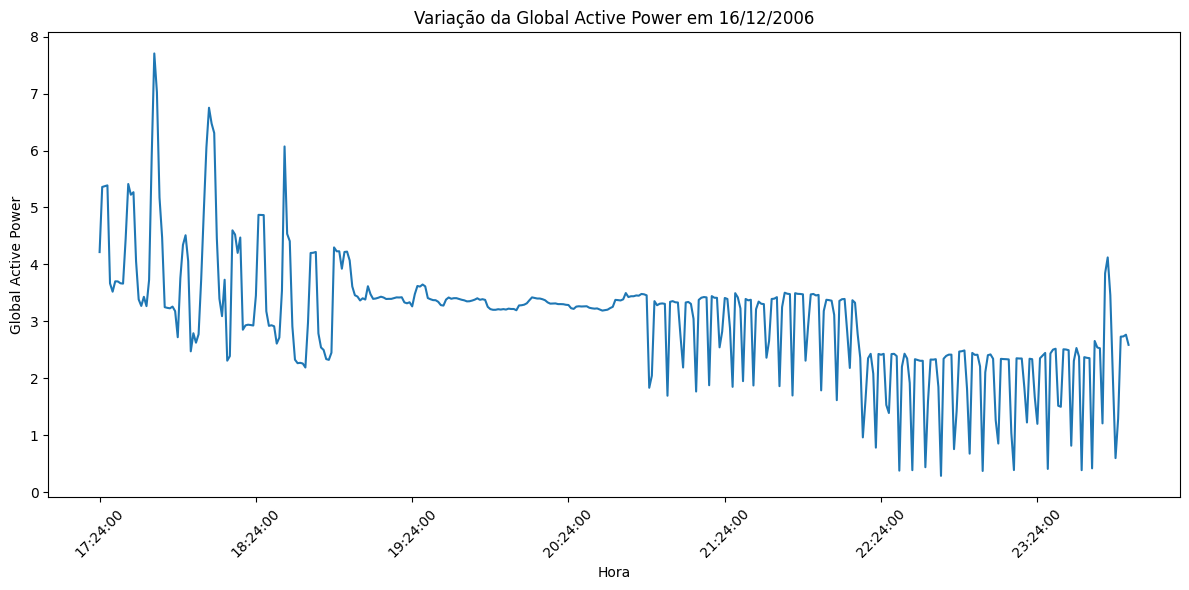

In [13]:
# Gerar um gráfico de linha com seaborn que mostra a variação da feature Global_ative_power em um único dia
import matplotlib.pyplot as plt

first_day = df['Date'].min()
df_one_day = df[df['Date'] == first_day]

plt.figure(figsize=(12, 6))
sb.lineplot(data=df_one_day, x='Time', y='Global_active_power')
plt.title(f'Variação da Global Active Power em {first_day.strftime("%d/%m/%Y")}')
plt.xlabel('Hora')
plt.ylabel('Global Active Power')
plt.xticks(df_one_day['Time'][::60], rotation=45) # Show ticks every 60 minutes
plt.tight_layout()
plt.show()

 7. Crie um histograma da variável Voltage. O que pode ser observado sobre sua distribuição?

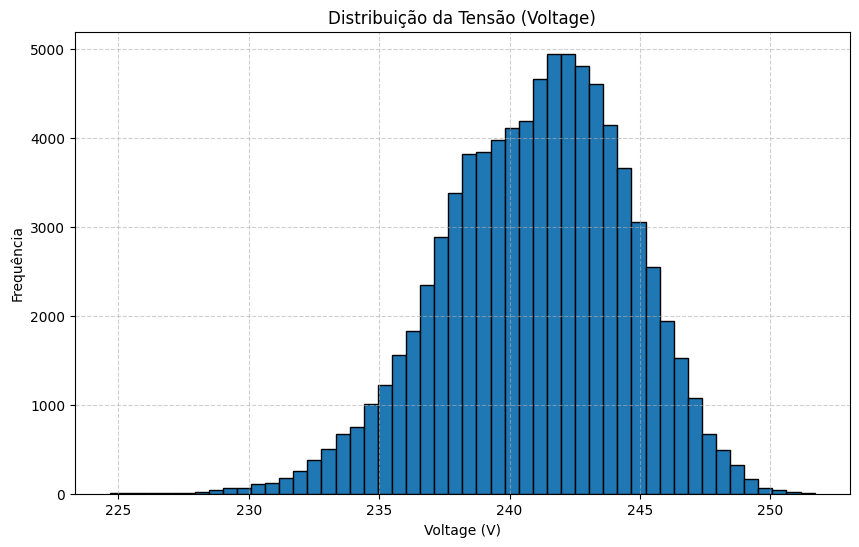

In [14]:
df['Voltage'] = pd.to_numeric(df['Voltage'], errors='coerce')

plt.figure(figsize=(10,6))
plt.hist(df['Voltage'].dropna(), bins=50, edgecolor='black')
plt.title('Distribuição da Tensão (Voltage)')
plt.xlabel('Voltage (V)')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

A distribuição do Voltage é aproximadamente normal, concentrada em torno de 240V, mostrando estabilidade na rede elétrica com pequenas variações e poucos valores extremos.

 8. Calcule o consumo médio por mês em todo o período disponível no dataset.


In [16]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

df['YearMonth'] = df['Date'].dt.to_period('M')
media_mensal = df.groupby('YearMonth')['Global_active_power'].mean()

display(media_mensal)

,Global_active_power
YearMonth,
2006-12,1.901295
2007-01,1.546034
2007-02,1.568987


9. Identifique o dia com maior consumo de energia ativa global (Global_active_power).

In [17]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

consumo_dia = df.groupby('Date')['Global_active_power'].sum()

dia_max = consumo_dia.idxmax()
valor_max = consumo_dia.max()

print(f"O dia de maior consumo foi {dia_max.strftime('%d/%m/%Y')} com {valor_max:.2f} kW")

O dia de maior consumo foi 23/12/2006 com 4773.39 kW


10. Compare o consumo médio de energia ativa global em dias de semana versus finais de
 semana.

In [18]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

media_semana_vs_fim = df.groupby(df['Day_of_Week'].isin(['Saturday', 'Sunday']).map({False: 'Dias de semana', True: 'Fins de semana'}))['Global_active_power'].mean()

print(media_semana_vs_fim)

Day_of_Week
Dias de semana    1.440217
Fins de semana    2.154276
Name: Global_active_power, dtype: float64


11 - Calcule a correlação entre as variáveis Global_active_power, Global_reactive_power, Voltage e Global_intensity.

In [19]:

cols_to_numeric = ['Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

correlation = df[['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']].corr()
display(correlation)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity
Global_active_power,1.000000,0.250045,-0.641641,0.998859
Global_reactive_power,0.250045,1.000000,-0.165345,0.261896
Voltage,-0.641641,-0.165345,1.000000,-0.647941
Global_intensity,0.998859,0.261896,-0.647941,1.000000


12 - Crie uma nova variável chamada Total_Sub_metering que some Sub_metering_1, Sub_metering_2 e Sub_metering_3.

In [20]:
df['Total_Sub_metering'] = df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']
display(df[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Total_Sub_metering']].head())

,Sub_metering_1,Sub_metering_2,Sub_metering_3,Total_Sub_metering
0,0.0,1.0,17.0,18.0
1,0.0,1.0,16.0,17.0
2,0.0,2.0,17.0,19.0
3,0.0,1.0,17.0,18.0
4,0.0,1.0,17.0,18.0


13 - Verifique se há algum mês em que Total_Sub_metering ultrapassa a média de Global_active_power.

In [21]:
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')[['Global_active_power', 'Total_Sub_metering']].mean()

display(monthly_avg)

months_exceeding_average = monthly_avg[monthly_avg['Total_Sub_metering'] > monthly_avg['Global_active_power']]

if not months_exceeding_average.empty:
    print("\nMonths where Total_Sub_metering exceeds the average Global_active_power:")
    display(months_exceeding_average)
else:
    print("\nThere are no months where Total_Sub_metering exceeds the average Global_active_power.")


,Global_active_power,Total_Sub_metering
Month,,
1,1.546034,10.423518
2,1.568987,11.135722
12,1.901295,10.873181



Months where Total_Sub_metering exceeds the average Global_active_power:


,Global_active_power,Total_Sub_metering
Month,,
1,1.546034,10.423518
2,1.568987,11.135722
12,1.901295,10.873181


14 - Faça um gráfico de série temporal do Voltage para o ano de 2008.

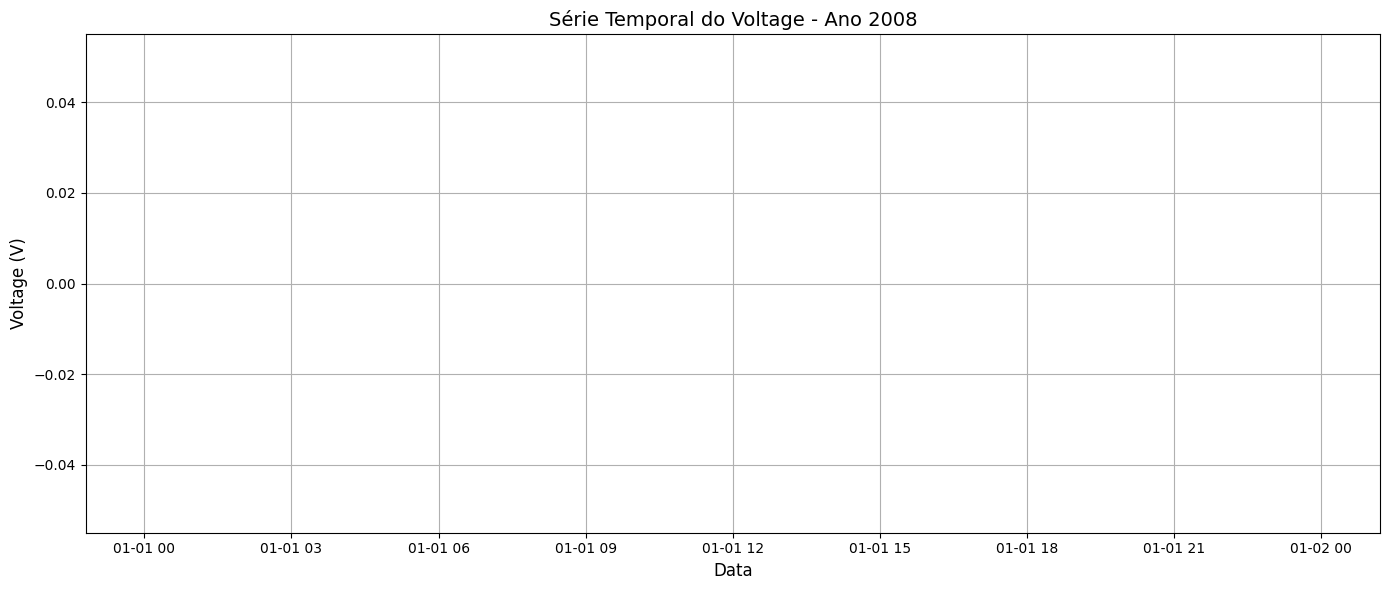

In [22]:
# Converter Date e Time para datetime
df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'],
                                 format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Converter Voltage para numérico
df['Voltage'] = pd.to_numeric(df['Voltage'], errors='coerce')

# Filtrar apenas o ano de 2008
df_2008 = df[df['DateTime'].dt.year == 2008]

# Plotar gráfico de série temporal
plt.figure(figsize=(14,6))
plt.plot(df_2008['DateTime'], df_2008['Voltage'], color='blue', linewidth=0.5)

plt.title("Série Temporal do Voltage - Ano 2008", fontsize=14)
plt.xlabel("Data", fontsize=12)
plt.ylabel("Voltage (V)", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

15 - Compare o consumo entre os meses de verão e inverno (no hemisfério norte).

In [23]:
summer_months = [6, 7, 8]  # June, July, August
winter_months = [12, 1, 2] # December, January, February

summer_consumption = df[df['Month'].isin(summer_months)]['Global_active_power'].mean()
winter_consumption = df[df['Month'].isin(winter_months)]['Global_active_power'].mean()

print(f"Average Global Active Power in Summer (Northern Hemisphere): {summer_consumption:.2f}")
print(f"Average Global Active Power in Winter (Northern Hemisphere): {winter_consumption:.2f}")

if summer_consumption > winter_consumption:
    print("\nAverage power consumption is higher in summer than in winter.")
elif winter_consumption > summer_consumption:
    print("\nAverage power consumption is higher in winter than in summer.")
else:
    print("\nAverage power consumption is similar in summer and winter.")

Average Global Active Power in Summer (Northern Hemisphere): nan
Average Global Active Power in Winter (Northern Hemisphere): 1.65

Average power consumption is similar in summer and winter.


21. Séries temporais por hora - Converta Date e Time em índice datetime. - Reamostre os dados em intervalos de 1 hora, calculando a média de Global_active_power. - Identifique os horários de maior consumo médio ao longo do dia. Observação: uma série temporal é um conjunto de dados registrados em ordem cronológica, útil para identificar padrões de comportamento ao longo do tempo.

In [43]:

df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'])

df = df.set_index('DateTime')
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

consumo_horario = df['Global_active_power'].resample('h').mean()

display(consumo_horario.head(10))
consumo_por_hora = consumo_horario.groupby(consumo_horario.index.hour).mean()

print(consumo_por_hora)

hora_max = consumo_por_hora.idxmax()
valor_max = consumo_por_hora.max()

print(f"Horário de maior consumo médio: {hora_max}:00 com {valor_max:.2f} kW")


,Global_active_power
DateTime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467
2006-12-16 22:00:00,2.200133
2006-12-16 23:00:00,2.061600
2006-12-17 00:00:00,1.882467
2006-12-17 01:00:00,3.349400


DateTime
0     1.183345
1     1.010914
2     0.871579
3     0.778043
4     0.821792
5     0.856164
6     1.097071
7     1.968359
8     2.141749
9     1.860211
10    1.739715
11    1.652831
12    1.567910
13    1.484411
14    1.487717
15    1.554491
16    1.698895
17    1.971023
18    2.488522
19    2.704938
20    2.757408
21    2.493560
22    1.846645
23    1.439802
Name: Global_active_power, dtype: float64
Horário de maior consumo médio: 20:00 com 2.76 kW


22. Autocorrelação do consumo - Use a série temporal de Global_active_power. - Calcule a autocorrelação em lags de 1h, 24h e 48h. - Pergunta: existem padrões repetidos diariamente?

In [27]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'])
df = df.set_index('DateTime')

consumo_horario = df['Global_active_power'].resample('h').mean()

lag_1h = consumo_horario.autocorr(lag=1)
lag_24h = consumo_horario.autocorr(lag=24)
lag_48h = consumo_horario.autocorr(lag=48)

print("Autocorrelação 1h:", lag_1h)
print("Autocorrelação 24h:", lag_24h)
print("Autocorrelação 48h:", lag_48h)

Autocorrelação 1h: 0.7576089625341951
Autocorrelação 24h: 0.259459151034302
Autocorrelação 48h: 0.18434347555031497


Se o valor de autocorrelação em 24h for alto e positivo (próximo de 1 ou pelo menos acima de aprox 0.5), isso indica que o consumo apresenta padrões repetidos diariamente.
O valor em 48h geralmente reforça esse comportamento, mas tende a ser um pouco menor que o de 24h.

23. Redução de dimensionalidade com PCA - Selecione Global_active_power, Global_reactive_power, Voltage e Global_intensity. - Aplique PCA para reduzir para 2 componentes principais. - Analise a variância explicada por cada componente.

In [30]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
df['Global_reactive_power'] = pd.to_numeric(df['Global_reactive_power'], errors='coerce')
df['Voltage'] = pd.to_numeric(df['Voltage'], errors='coerce')
df['Global_intensity'] = pd.to_numeric(df['Global_intensity'], errors='coerce')

X = df[['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
print("Variância explicada por cada componente:", explained_var)
print("Variância total explicada (2 componentes):", explained_var.sum())


Variância explicada por cada componente: [0.65873677 0.22700987]
Variância total explicada (2 componentes): 0.8857466365571718


24. Visualização de clusters no espaço PCA - Combine os resultados do PCA com K-Means (3 clusters). - Plote os pontos resultantes e pinte cada grupo por cluster. - Pergunta: os grupos se separam de forma clara?

<Axes: xlabel='PC1', ylabel='PC2'>

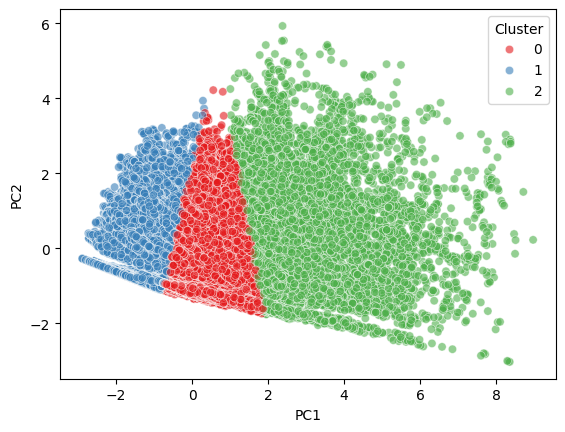

In [35]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters

sb.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='Set1', alpha=0.6)

Se os clusters aparecem bem separados no gráfico, significa que os dados possuem estruturas naturais distintas (boa separação).

Se houver sobreposição forte entre cores, então os clusters não estão bem definidos, e pode ser necessário aumentar o número de variáveis no PCA ou ajustar o número de clusters.

25. Regressão polinomial vs linear - Modele Global_active_power em função de Voltage. - Compare Regressão Linear Simples com Regressão Polinomial (grau 2). - Analise RMSE e a curva ajustada.

RMSE - Linear: 1.0269
RMSE - Polinomial (grau 2): 1.0053


<Axes: xlabel='Voltage', ylabel='Global_active_power'>

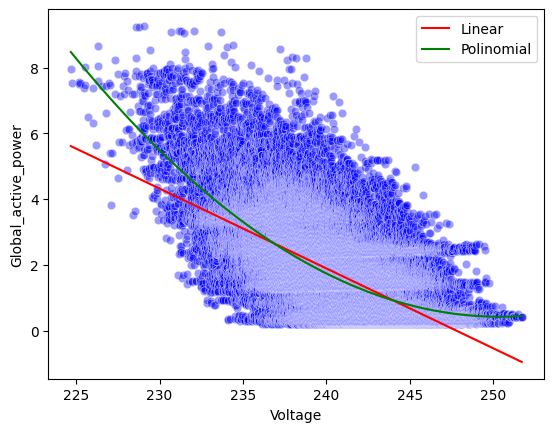

In [41]:
df["Voltage"] = pd.to_numeric(df["Voltage"], errors="coerce")
df["Global_active_power"] = pd.to_numeric(df["Global_active_power"], errors="coerce")

df_model = df[["Voltage", "Global_active_power"]].dropna()

X = df_model[["Voltage"]]
y = df_model["Global_active_power"]

linear_model = LinearRegression()
linear_model.fit(X, y)
y_pred_linear = linear_model.predict(X)

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_pred_poly = poly_model.predict(X_poly)

rmse_linear = np.sqrt(mean_squared_error(y, y_pred_linear))
rmse_poly = np.sqrt(mean_squared_error(y, y_pred_poly))

print(f"RMSE - Linear: {rmse_linear:.4f}")
print(f"RMSE - Polinomial (grau 2): {rmse_poly:.4f}")

df_plot = df_model.copy()
df_plot["Linear"] = y_pred_linear
df_plot["Polinomial"] = y_pred_poly

df_plot = df_plot.sort_values("Voltage")

sb.scatterplot(x="Voltage", y="Global_active_power", data=df_plot, color="blue", alpha=0.4)
sb.lineplot(x="Voltage", y="Linear", data=df_plot, color="red", label="Linear")
sb.lineplot(x="Voltage", y="Polinomial", data=df_plot, color="green", label="Polinomial")